Santiago Baeza

# Trayectorias

# Clase 9 - 14/09/2026

In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [25]:
S0 = 100
r = 0.05
sigma = 0.20
k = 100
dt = 1/252
periodo = 252
rutas = 50

z=np.random.normal(0,1,50)

Simulación de 50 trayectorias

In [26]:
rutas_50 = 50
trayectorias_50 = np.zeros((periodo + 1, rutas_50))
trayectorias_50[0] = S0

for i in range(1, periodo + 1):
    z = np.random.normal(0, 1, rutas_50)
    trayectorias_50[i] = trayectorias_50[i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)


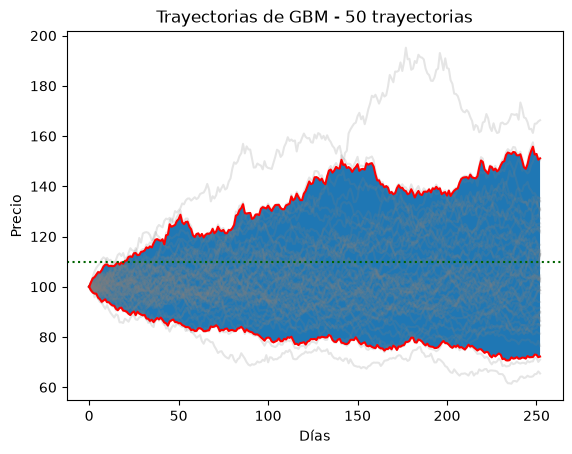

In [27]:
p975 = np.percentile(trayectorias_50, 97.5, axis=1)
p025 = np.percentile(trayectorias_50, 2.5, axis=1)
dias = np.arange(len(p025))

plt.plot(trayectorias_50, color="grey", alpha=0.2)
plt.plot(p975,color="red")
plt.plot(p025,color="red")
plt.fill_between(dias,p025,p975)
plt.title("Trayectorias de GBM - 50 trayectorias")
plt.xlabel("Días")
plt.ylabel("Precio")
plt.axhline(110, color="darkgreen", linestyle=":")
plt.show()

Simulación de 1000 trayectorias

In [28]:
rutas_1000 = 1000
trayectorias_1000 = np.zeros((periodo + 1, rutas_1000))
trayectorias_1000[0] = S0

for i in range(1, periodo + 1):
    z = np.random.normal(0, 1, rutas_1000)
    trayectorias_1000[i] = trayectorias_1000[i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

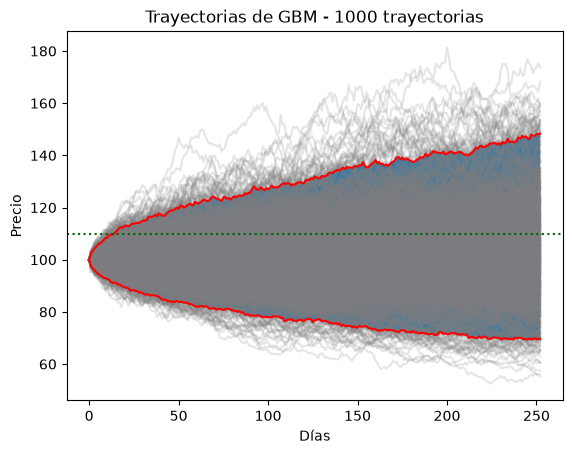

In [29]:
p975 = np.percentile(trayectorias_1000, 97.5, axis=1)
p025 = np.percentile(trayectorias_1000, 2.5, axis=1)
dias = np.arange(len(p025))

plt.plot(trayectorias_1000, color="grey", alpha=0.2)
plt.plot(p975,color="red")
plt.plot(p025,color="red")
plt.fill_between(dias,p025,p975)
plt.title("Trayectorias de GBM - 1000 trayectorias")
plt.xlabel("Días")
plt.ylabel("Precio")
plt.axhline(110, color="darkgreen", linestyle=":")
plt.show()

Promedio de trayectoria para opción asiática

In [30]:
promedios_asiatica = np.mean(trayectorias_1000, axis=0)
print(promedios_asiatica)

[105.6846965   88.21350432  95.14205475  96.2567796  110.59329848
  94.42405123  98.44466531  98.57011455 108.65880452 100.15126896
  95.44116536  92.99989993  85.21461346 121.46981533 110.17609296
 106.57741807 100.69697518 100.23955054 105.93292259 112.17298826
  93.21507512 108.47678286 138.45769056 105.89196436 114.53933995
 104.34698756  88.13418312 112.9900124   89.30422136  97.28109983
  76.14819627  81.79720801  94.5011446  112.89820408  97.87828886
 124.80636561 124.1815256   90.94530007  92.18390305  89.89053977
  96.05949375  88.08320454  88.58568996 103.52871124 107.44631913
  93.16782324  83.73409594 108.83736424 104.16687648 117.85114567
  96.31395782 107.72125287 107.26648084 101.39865433  97.16280491
 109.24146615 112.76969779  83.61903345 106.9564012  110.08473338
  80.71859837  98.99852474 108.15967521 115.70962377  91.37876665
  88.63668013 105.33043549 103.97521501  97.13704976 113.11512599
  85.00083156 119.74902117  78.20558021  95.84158127  93.60834837
 112.54383

Histograma con payoffs de opción europea y opción asiática

In [31]:
payoffs_europea = np.maximum(trayectorias_1000[-1] - k, 0)
payoffs_asiatica = np.maximum(promedios_asiatica - k, 0)

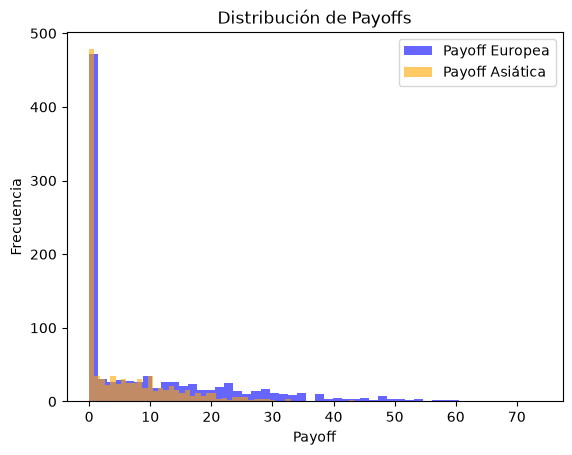

In [32]:
plt.hist(payoffs_europea, bins=50, alpha=0.6, label='Payoff Europea', color='blue')
plt.hist(payoffs_asiatica, bins=50, alpha=0.6, label='Payoff Asiática', color='orange')
plt.title("Distribución de Payoffs")
plt.xlabel("Payoff")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Cálculo de precio de opciones y comparación

In [33]:
T = periodo * dt
precio_europea = np.exp(-r * T) * np.mean(payoffs_europea)
precio_asiatica = np.exp(-r * T) * np.mean(payoffs_asiatica)

print(precio_europea)
print(precio_asiatica)

9.636526827984575
5.304588519574817
